# Part 1: JAX Foundations

**Goal**: Build a working mental model of JAX by learning how it uses arrays, why it bans mutation, and how/why it uses its random number system. By the end, you'll implement a neural network forward pass from scratch in idiomatic JAX.

---

## Table of Contents

1. **Introduction to JAX**
2. **The Transition from NumPy to JAX**
3. **Immutability and Purity**
4. **Array Semantics**
5. **Random Number Generation**
6. **Common Misconceptions**
7. **Neural Network Forward Pass Example**
8. **Summary**


> **Prerequisites**: Basic Python knowledge (variables, functions, loops). Familiarity with NumPy array operations is helpful but not required — we'll explain the differences as we go.


In [1]:
# @title Setup { display-mode: "form" }

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

print(f"JAX version:  {jax.__version__}")
print(f"Devices:      {jax.devices()}")
print(f"Default backend: {jax.default_backend()}")


JAX version:  0.9.2
Devices:      [CpuDevice(id=0)]
Default backend: cpu


---

# 1. Introduction to JAX

## The Core Idea

> **JAX is a system for composable function transformations over array programs.**

Let's break down exactly what this means. While JAX is often introduced as "NumPy on accelerators" or "an automatic differentiation engine", these descriptions miss the larger picture.

JAX is fundamentally built around **two distinct layers**:

1. **Array Programs ([`jax.numpy`](https://jax.readthedocs.io/en/latest/jax.numpy.html))**: You write familiar, standard Python code that performs array math, much like you would using traditional NumPy. JAX provides a seamless API to execute this math on CPU, GPU, or TPU.

2. **Function Transformations ([`jax`](https://jax.readthedocs.io/en/latest/jax.html) top-level API)**: JAX's true power lies in its ability to take the Python functions you've written and *transform* them into completely new functions. The primary transformations are:
   * [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html): Compiles your function using XLA (Accelerated Linear Algebra, a compiler that optimizes computations for CPUs, GPUs, and TPUs) for massive speedups on accelerators (specialized hardware like GPUs and TPUs designed to perform large-scale math far faster than CPUs).

   * [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html): Takes a function and returns a new function that computes its gradients.

   * [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html): Takes a function designed for a single input and returns a new function that handles batched inputs automatically.

### The Power of Composition
Because transformations consume a function and return a function, they can be freely stacked (composed). You can take a single-item computation, batch it over a dataset ([`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html)), take its gradient with respect to model weights ([`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html)), and compile the whole entire process into a highly optimized accelerator operation ([`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html)). Constructing pipelines like [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html)([`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html)([`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html)(f))) is the primary JAX workflow.

### A Shift in Programming Paradigm
If you are coming from traditional Object-Oriented ML frameworks (like PyTorch or TensorFlow), JAX requires a paradigm shift.

* **No hidden state**: You do not build a stateful computational graph object.

* **No `Module` objects**: You do not subclass a class to encapsulate and mutate parameters internally.

* **Pure functions**: You write pure Python functions where data and parameters are passed in explicitly as arguments, resulting in deterministic array outputs.

By strictly adhering to these functional programming constraints, JAX guarantees that its function transformations are safe, reliable, and mathematically sound.


---

# 2. The Transition from NumPy to JAX

## JAX vs. NumPy
| | **NumPy** | **JAX** |
|---|---|---|
| **Paradigm** | Imperative | Functional transformations |
| **Mutability** | Mutable arrays | Immutable arrays |
| **Compilation** | None (interpreted) | [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) traces → XLA compiles |
| **Differentiation** | None | [`grad(f)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) returns a new function |
| **Batching** | Manual reshaping | [`vmap(f)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html) returns a new function |
| **Device model** | CPU only | Arrays placed at creation; transforms are device-aware |

The key insight: in JAX, **transformations return new functions**. [`grad(f)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) doesn't mutate `f` or compute a gradient — it returns a *new function* that computes the gradient. This is what makes composition possible.

## jax.numpy API

[`jax.numpy`](https://jax.readthedocs.io/en/latest/jax.numpy.html) mirrors the NumPy API almost exactly. If you know NumPy, you already know ~95% of [`jax.numpy`](https://jax.readthedocs.io/en/latest/jax.numpy.html). However, there are important operational differences to note.

> **Important**: NumPy defaults to 64-bit floating point (`float64`), but JAX defaults to 32-bit (`float32`). This can cause subtle numerical differences when porting NumPy code to JAX.


In [2]:
# Array creation — looks exactly like NumPy
a = jnp.array([1.0, 2.0, 3.0])
b = jnp.ones((3, 3))
c = jnp.linspace(0, 1, 5)

print("Array creation:")
print(f"  a = {a}")
print(f"  b shape = {b.shape}")
print(f"  c = {c}")

# Standard operations — same API
print(f"\nOperations:")
print(f"  jnp.dot(a, a) = {jnp.dot(a, a)}")
print(f"  jnp.mean(b)   = {jnp.mean(b)}")
print(f"  jnp.sin(c)    = {jnp.sin(c)}")

# Slicing, reshaping, broadcasting — all familiar
x = jnp.arange(12).reshape(3, 4)
print(f"\nSlicing and reshaping:")
print(f"  x[0, :2] = {x[0, :2]}")
print(f"  x.T shape = {x.T.shape}")


Array creation:
  a = [1. 2. 3.]
  b shape = (3, 3)
  c = [0.   0.25 0.5  0.75 1.  ]

Operations:
  jnp.dot(a, a) = 14.0
  jnp.mean(b)   = 1.0
  jnp.sin(c)    = [0.         0.24740396 0.47942555 0.6816388  0.84147096]

Slicing and reshaping:
  x[0, :2] = [0 1]
  x.T shape = (4, 3)


## Broadcasting: The `[:, None]` Trick

A constant source of errors in tensor math is shape mismatch. In standard Python, you might manually write loops, but in JAX you use vectorized operations. When vectorizing math, you frequently need to align array dimensions by padding them with "dummy" dimensions of size `1`.

JAX (like NumPy) broadcasts by aligning shapes **from the right** (trailing axes). A 1-D vector of shape `(4,)` is implicitly treated as `(1, 4)` — matching against the **columns** of a matrix, not the rows. So adding it to a `(4, 3)` matrix fails because the trailing axes are 4 and 3, which don’t match.

While you can use [`.reshape()`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.reshape.html), the standard idiom is to use `[:, None]` or `jnp.newaxis`. It injects a size-1 axis that turns the vector into a column shape `(4, 1)`, whose trailing axis of 1 broadcasts freely against any number of columns.

In [3]:
vector = jnp.array([1.0, 2.0, 3.0, 4.0])    # Shape: (4,)
matrix = jnp.ones((4, 3))                    # Shape: (4, 3)

print(f"vector shape: {vector.shape}")
print(f"matrix shape: {matrix.shape}\n")

# Broadcasting aligns shapes from the RIGHT (trailing axes).
# vector (4,) is treated as (1, 4) -> trailing axes are 4 vs 3: MISMATCH!
# Even though the matrix has 4 rows and the vector has 4 elements,
# JAX aligns against columns, not rows.
try:
    res = matrix + vector
except Exception as e:
    print(f"Error: {e}")

# Fix: inject a dummy axis to make it a column vector (4, 1).
# Now trailing axes are 1 vs 3: broadcasts freely to (4, 3).
column = vector[:, None]                    # Shape: (4, 1)
print(f"column shape: {column.shape}")

res = matrix + column                       # (4, 3) + (4, 1) -> (4, 3)
print(f"Success! Result shape: {res.shape}")


vector shape: (4,)
matrix shape: (4, 3)

Error: Incompatible shapes for broadcasting: shapes=[(4, 3), (4,)]
column shape: (4, 1)
Success! Result shape: (4, 3)


## From NumPy Habits to JAX Patterns

Here's a quick translation table for the patterns that are useful to know:

| NumPy Pattern | JAX Equivalent | Why |
|---|---|---|
| `a[i] = v` | [`a = a.at[i].set(v)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) | Immutability |
| `np.random.randn(3)` | [`jax.random.normal(key, (3,))`](https://jax.readthedocs.io/en/latest/_autosummary/jax.random.normal.html) | Explicit PRNG (Section 5) |
| `a.sort()` | [`a = jnp.sort(a)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.sort.html) | No in-place sort |
| `np.concatenate` | [`jnp.concatenate`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.concatenate.html) | Same API, different backend |
| `if a > 0:` (on array) | [`jnp.where(a > 0, ...)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.numpy.where.html) | Traceable control flow |
| `for i in range(n):` | Often [`jax.lax.scan`](https://jax.readthedocs.io/en/latest/_autosummary/jax.lax.scan.html) | Efficient under JIT ([Notebook 06](07_control_flow.ipynb)) |

---

# 3. Immutability and Purity

Here's where JAX diverges significantly. NumPy lets you modify arrays in place:

```python
# NumPy — this works
a = np.zeros(5)
a[2] = 99.0  # In-place mutation
```

JAX arrays are **immutable**. The equivalent operation in JAX uses a different syntax:


In [4]:
# --- NumPy: in-place mutation ---
np_arr = np.zeros(5)
print(f"NumPy initial:  {np_arr}")
np_arr[2] = 99.0
print(f"NumPy (mutated in place):  {np_arr}")

# --- JAX: .at[].set() returns a NEW array ---
jax_arr = jnp.zeros(5)
print(f"\nJAX initial: {jax_arr}")
jax_new = jax_arr.at[2].set(99.0)

print(f"JAX original (not mutated): {jax_arr}")
print(f"JAX new (copy with changed data):   {jax_new}")


NumPy initial:  [0. 0. 0. 0. 0.]
NumPy (mutated in place):  [ 0.  0. 99.  0.  0.]

JAX initial: [0. 0. 0. 0. 0.]
JAX original (not mutated): [0. 0. 0. 0. 0.]
JAX new (copy with changed data):   [ 0.  0. 99.  0.  0.]


The [`.at[]`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) API supports all the update operations you'd expect:

| NumPy (in-place) | JAX (returns new array) |
|---|---|
| `a[idx] = val` | [`a.at[idx].set(val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) |
| `a[idx] += val` | [`a.at[idx].add(val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) |
| `a[idx] *= val` | [`a.at[idx].mul(val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) |
| `a[idx] = np.maximum(a[idx], val)` | [`a.at[idx].max(val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) |
| `a[idx] = np.minimum(a[idx], val)` | [`a.at[idx].min(val)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) |

Immutability is **not** just a stylistic preference — it's a hard requirement for JAX's transformation system to work correctly. We'll see why in Section 4.


> **Note on `.max` and `.min`**: `a.at[idx].max(val)` keeps whichever is larger — the existing element at `idx` or `val`. It is an element-wise conditional update, **not** a global reduction over the array.


In [5]:
# Scatter updates
x = jnp.zeros((4, 4))
x = x.at[0, :].set(1.0)          # Set first row
x = x.at[:, -1].add(10.0)        # Add to last column
x = x.at[jnp.diag_indices(4)].set(-1.0)  # Set diagonal
print("Scatter update result:")
print(x)

# Out-of-bounds indexing: JAX clamps instead of raising
arr = jnp.array([10, 20, 30])
print(f"\nOut-of-bounds (index=5, length=3): {arr[5]}")
print("NumPy would raise IndexError. JAX clamps to the last element.")


Scatter update result:
[[-1.  1.  1. 11.]
 [ 0. -1.  0. 10.]
 [ 0.  0. -1. 10.]
 [ 0.  0.  0. -1.]]

Out-of-bounds (index=5, length=3): 30
NumPy would raise IndexError. JAX clamps to the last element.


> **Why clamp instead of raising an error?** Inside a JIT-compiled kernel, raising a Python exception at runtime is impossible — the compiled code runs on the device, not in Python. Returning a deterministic (clamped) value is the only option that keeps kernels safe and branchless.


## Why Immutability? The Functional Contract

> **JAX transformations only see what flows through function arguments and return values. Everything else is invisible.**

Immutability is **not** just a stylistic preference — it’s fundamental to how JAX’s transformations work. When you apply [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html), or [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html) to a function, JAX **traces** it. Tracing is the process where JAX runs your function once with special placeholder values (called *tracers*) instead of real numbers. It doesn’t compute anything — it just records *which operations* your function performs and in what order, building a computational recipe that can be optimized and replayed. Anything that doesn’t flow through the arguments and return value (global state, in-place mutation, print statements, random state) is invisible to the trace.

This means:


In [6]:
# --- Example 1: Mutation is invisible ---
external_list = []

def bad_function(x):
    external_list.append(x)  # Side effect! JAX can't see this.
    return x + 1

# Under jit, the side effect happens at TRACE time, not at call time
jitted_bad = jax.jit(bad_function)

print("Before any calls:", len(external_list))
result1 = jitted_bad(jnp.array(1.0))
print("After first call:", len(external_list), " (traced once)")
result2 = jitted_bad(jnp.array(2.0))
print("After second call:", len(external_list), " (used cached trace, no re-trace)")


Before any calls: 0
After first call: 1  (traced once)
After second call: 1  (used cached trace, no re-trace)


In [7]:
# The @ decorator is Python shorthand to pass this function through jax.jit()
@jax.jit
def traced_function(x):
    print("This prints during TRACING, not during execution!")  # <-- only runs once
    return x * 2

print("--- First call (triggers tracing + compilation): ---")
result1 = traced_function(jnp.array(3.0))
print(f"Result: {result1}")

print("\n--- Second call (uses cached compilation): ---")
result2 = traced_function(jnp.array(7.0))
print(f"Result: {result2}")
print("\nNotice: the print inside the function did NOT run the second time.")
print("Use jax.debug.print() for prints that run every call (covered in Notebook 09).")


--- First call (triggers tracing + compilation): ---
This prints during TRACING, not during execution!
Result: 6.0

--- Second call (uses cached compilation): ---
Result: 14.0

Notice: the print inside the function did NOT run the second time.
Use jax.debug.print() for prints that run every call (covered in Notebook 09).


## Why This Matters

The functional contract — pure functions in, transformed functions out — is what enables JAX's killer feature: **composable transformations**. Because [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html) can trust that a function has no hidden state, it can safely transform it. Because [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) can trust that a function is deterministic given its inputs, it can safely cache the compiled version.

> **The immutability "restriction" is actually what makes [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html)([`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html)([`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html)(f))) possible.**

If you find yourself fighting immutability, you're likely trying to write imperative code in a functional system. The fix is almost always to pass state explicitly through function arguments and return values.

---

# 4. Array Semantics

## Device Placement

JAX arrays live on a specific device (CPU, GPU, or TPU). Unlike many other ML frameworks, you typically don't explicitly move tensors around between devices mid-computation. Arrays are placed when they're created, and operations happen where the data lives.


In [8]:
x = jnp.ones((3, 3))
print(f"Array device: {x.devices()}")

# Arrays know where they live:
print(f"Backend: {jax.default_backend()}")
print(f"Available devices: {jax.devices()}")


Array device: {CpuDevice(id=0)}
Backend: cpu
Available devices: [CpuDevice(id=0)]


## Timing JAX Code: `block_until_ready()`

JAX uses **asynchronous dispatch** (meaning it sends work to the hardware and immediately returns control to Python without waiting for the result) — when you call a JAX operation, Python gets control back *before the computation finishes*. The result is a future that blocks only when you actually read the value. This is great for throughput but it makes naive timing wrong.

> **Analogy**: Think of it like starting a file download and immediately moving on — the download runs in the background, and you only wait for it when you actually need the file. `block_until_ready()` is the "wait for the download to finish" step.

In [9]:
import time

x = jnp.ones((2000, 2000))

# WRONG — this measures dispatch time, not computation time
start = time.time()
y = jnp.dot(x, x)
wrong_time = time.time() - start

# RIGHT — block until the result is actually computed
start = time.time()
y = jnp.dot(x, x)
y.block_until_ready()
right_time = time.time() - start

print(f"Without block_until_ready: {wrong_time*1000:.2f} ms  (measures dispatch only)")
print(f"With block_until_ready:    {right_time*1000:.2f} ms  (measures actual computation)")
print(f"\nThe first call also includes compilation time.")
print(f"For accurate benchmarks, always warm up first, then time with block_until_ready().")


Without block_until_ready: 4.28 ms  (measures dispatch only)
With block_until_ready:    42.20 ms  (measures actual computation)

The first call also includes compilation time.
For accurate benchmarks, always warm up first, then time with block_until_ready().


---

# 5. Random Number Generation: JAX's PRNG (Pseudo-Random Number Generator)

JAX uses a different approach to random number generation compared to NumPy. Every other library uses global random state:

```python
np.random.seed(42)
x = np.random.randn(3)  # Draws from global state, advances it
y = np.random.randn(3)  # Gets different numbers (state advanced)
```

JAX can't do this. Global state is a side effect, and side effects are invisible to transformations.

In [10]:
# np.random inside a jitted function gives the SAME result every call
# because the random call happens at trace time, not execution time.

# The @ decorator is Python shorthand to pass this function through jax.jit()
@jax.jit
def bad_random(x):
    noise = np.random.randn()  # Uses NumPy global state — BAD
    return x + noise

# Call it multiple times
results = [float(bad_random(jnp.array(0.0))) for _ in range(5)]
print("np.random inside jit:")
for i, r in enumerate(results):
    print(f"  Call {i+1}: {r:.6f}")
print("\nSame result every time! The np.random.randn() was baked into the")
print("compiled trace as a constant.")


np.random inside jit:
  Call 1: -0.687101
  Call 2: -0.687101
  Call 3: -0.687101
  Call 4: -0.687101
  Call 5: -0.687101

Same result every time! The np.random.randn() was baked into the
compiled trace as a constant.


## Keys, Splitting, and Subkeys

JAX replaces global state with **explicit PRNG keys**. A key is a pair of 32-bit integers that deterministically produces random numbers.

The mental model:

> **A key acts as the PRNG state. Splitting generates new states.**

You start with one key. Every time you need randomness, you **split** the key into subkeys — one for each random draw — and you never reuse a key.

In [11]:
# Create a key from a seed
key = jax.random.PRNGKey(42)
print(f"Original key: {key}")
print(f"Key dtype: {key.dtype}, shape: {key.shape}")

# Split into subkeys
key, subkey1, subkey2 = jax.random.split(key, 3)
print(f"\nAfter split:")
print(f"  New key:  {key}")
print(f"  Subkey 1: {subkey1}")
print(f"  Subkey 2: {subkey2}")

# Draw random numbers using subkeys
x = jax.random.normal(subkey1, shape=(3,))
y = jax.random.normal(subkey2, shape=(3,))
print(f"\nDrawn from subkey1: {x}")
print(f"Drawn from subkey2: {y}")
print("\nDifferent subkeys → different (independent) random numbers.")


Original key: [ 0 42]
Key dtype: uint32, shape: (2,)

After split:
  New key:  [1832780943  270669613]
  Subkey 1: [  64467757 2916123636]
  Subkey 2: [2465931498  255383827]

Drawn from subkey1: [ 0.60576403  0.7990441  -0.908927  ]
Drawn from subkey2: [ 0.4323065  0.5872638 -1.1416743]

Different subkeys → different (independent) random numbers.


In [12]:
key = jax.random.PRNGKey(0)

# Reusing the same key gives the SAME random numbers
a = jax.random.normal(key, shape=(3,))
b = jax.random.normal(key, shape=(3,))
print(f"Same key, call 1: {a}")
print(f"Same key, call 2: {b}")
print(f"Identical? {jnp.allclose(a, b)}")
print("\nThis is BY DESIGN — same key = same result = reproducibility.")
print("If you want different numbers, use different keys (split first).")


Same key, call 1: [ 1.6226422   2.0252647  -0.43359444]
Same key, call 2: [ 1.6226422   2.0252647  -0.43359444]
Identical? True

This is BY DESIGN — same key = same result = reproducibility.
If you want different numbers, use different keys (split first).


## The Splitting Pattern

The standard pattern for managing keys is to split before each usage:

```python
key = jax.random.PRNGKey(seed)

# Every time you need randomness:
key, subkey = jax.random.split(key)
samples = jax.random.normal(subkey, shape=(...))
```

Split first, draw second. The `key` variable advances each time, and `subkey` is consumed for the draw. This is analogous to `np.random.seed(42)` followed by `np.random.randn()`, except the state management is explicit instead of hidden.

> **Note**: In newer JAX versions (0.4.26+), `jax.random.key(seed)` is the preferred way to create keys, replacing `jax.random.PRNGKey(seed)`. Both work identically, but `key()` is the modern API.

In [13]:
key = jax.random.PRNGKey(0)

print("Sequential draws with proper splitting:")
for i in range(5):
    key, subkey = jax.random.split(key)
    sample = jax.random.normal(subkey, shape=(1,))
    print(f"  Draw {i+1}: {sample.item():.6f}")

print("\nEach draw is different because each uses a different subkey.")
print("But the ENTIRE sequence is reproducible — run this cell again and you get the same numbers.")


Sequential draws with proper splitting:
  Draw 1: -2.442456
  Draw 2: -1.257478
  Draw 3: -1.387768
  Draw 4: -2.302266
  Draw 5: -1.014780

Each draw is different because each uses a different subkey.
But the ENTIRE sequence is reproducible — run this cell again and you get the same numbers.


## PRNG and Transformations

The explicit key system isn't just for reproducibility — it's what makes randomness work correctly under [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) and [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html).

| Pattern | How It Works |
|---|---|
| **jit** | Key flows through args → no side effects → safe to compile |
| **vmap** | Split N keys, vmap over them → independent randomness per batch element |
| **grad** | Key is non-differentiable → passes through unchanged |

In [14]:
# Works perfectly under jit — key is an explicit argument
# The @ decorator is Python shorthand to pass this function through jax.jit()
@jax.jit
def random_add(key, x):
    noise = jax.random.normal(key, shape=x.shape)
    return x + 0.1 * noise

key = jax.random.PRNGKey(42)
x = jnp.ones(4)

# Each call with a different key gives different results
key, k1, k2 = jax.random.split(key, 3)
print("jit + PRNG:")
print(f"  Key 1: {random_add(k1, x)}")
print(f"  Key 2: {random_add(k2, x)}")

# Works perfectly under vmap — one key per batch element
keys = jax.random.split(key, 8)  # 8 independent keys
batch = jnp.ones((8, 4))
results = jax.vmap(random_add)(keys, batch)
print(f"\nvmap + PRNG (8 independent samples):")
print(f"  Shape: {results.shape}")
print(f"  Row 0: {results[0]}")
print(f"  Row 1: {results[1]}")
print("  Each row used a different key → independent noise.")


jit + PRNG:
  Key 1: [1.0605764  1.0799044  0.90910727 0.93647426]
  Key 2: [1.0432307  1.0587264  0.88583255 0.9626201 ]

vmap + PRNG (8 independent samples):
  Shape: (8, 4)
  Row 0: [0.9280203  1.1552181  0.91442645 1.0270705 ]
  Row 1: [0.978911   0.86372054 0.9954996  0.88463604]
  Each row used a different key → independent noise.


---

# 6. Common Misconceptions

## Misconception: "JAX is just NumPy on accelerators"

JAX *includes* a NumPy-compatible API, but the API compatibility is primarily a convenient entry point. The real power — [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html), [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html), and their composition — has nothing to do with NumPy. You could build JAX's transformation system on top of any array library; NumPy compatibility just makes adoption easier.

## Misconception: "I should convert all my code to JAX"

No. Use NumPy for data loading, preprocessing, and anything that runs once. Use JAX for the computation you want to differentiate, compile, or vectorize. A typical program has NumPy at the edges (I/O, data wrangling) and JAX in the core (model forward pass, loss computation, training step).

```python
# Good pattern
data = np.load("data.npy")              # NumPy for I/O
data = np.random.permutation(data)       # NumPy for shuffling
batch = jnp.array(data[:32])             # Convert at the boundary
loss = jitted_loss_fn(params, batch)     # JAX for computation
```

## Misconception: "In-place operations are just syntax sugar — they work the same underneath"

This is a meaningful difference. In NumPy, `a[0] = 1` modifies memory in place. In JAX, [`a.at[0].set(1)`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) creates a *new* array. If you accidentally rely on mutation (e.g., building up an array in a loop with index assignment), your code will silently produce incorrect results under [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) because the mutation happened at trace time, not execution time. The functional [`.at[].set()`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) pattern is the only safe approach.

## Misconception: "Splitting PRNG keys is expensive"

Splitting is a fast, deterministic hash — essentially a few XOR and rotate operations. It's cheaper than most array operations you'll call with the resulting key. Explicit key management does not introduce significant computational overhead.

---

# 7. Capstone: Your First Neural Network Forward Pass

A **forward pass** is the process of computing an output from an input by feeding data through each layer of the network sequentially.

Let's combine everything from this notebook: array operations, immutability, and the PRNG system. We'll build a simple 2-hidden-layer MLP (Multi-Layer Perceptron — the simplest kind of neural network, a stack of layers where each layer's output feeds into the next) in pure JAX — no frameworks, no magic.

The key principles in action:
- **Pure functions**: the forward pass is a function of `(params, x)` — no hidden state
- **Explicit randomness**: weight initialization uses proper key splitting
- **Immutable data**: parameters are a plain Python data structure (list of tuples), not a mutable object

In [15]:
def init_mlp_params(key, layer_sizes):
    """Initialize MLP parameters with He initialization.

    Args:
        key: PRNG key
        layer_sizes: list of ints, e.g. [784, 256, 128, 10]

    Returns:
        List of (weight, bias) tuples — one per layer.
    """
    params = []
    for i in range(len(layer_sizes) - 1):
        key, w_key, b_key = jax.random.split(key, 3)
        fan_in = layer_sizes[i]
        fan_out = layer_sizes[i + 1]

        # He initialization (named after Kaiming He): scales weights based on
        # the layer's input size to prevent activations from exploding or vanishing.
        # Scale = sqrt(2 / fan_in)
        w = jax.random.normal(w_key, (fan_in, fan_out)) * jnp.sqrt(2.0 / fan_in)
        b = jnp.zeros(fan_out)
        params.append((w, b))

    return params

# Initialize a 3-layer MLP: input(8) → hidden(64) → hidden(32) → output(1)
key = jax.random.PRNGKey(42)
layer_sizes = [8, 64, 32, 1]
params = init_mlp_params(key, layer_sizes)

print("MLP Architecture:")
for i, (w, b) in enumerate(params):
    print(f"  Layer {i}: weight {w.shape}, bias {b.shape}")


MLP Architecture:
  Layer 0: weight (8, 64), bias (64,)
  Layer 1: weight (64, 32), bias (32,)
  Layer 2: weight (32, 1), bias (1,)


In [16]:
def mlp_forward(params, x):
    """Forward pass through an MLP.

    Args:
        params: list of (weight, bias) tuples
        x: input array of shape (features,)

    Returns:
        Output array — shape depends on last layer.
    """
    for i, (w, b) in enumerate(params):
        x = x @ w + b  # @ is Python's matrix multiplication operator
        # ReLU (Rectified Linear Unit) activation: max(x, 0).
        # This simple non-linearity is applied on all but the last layer.
        if i < len(params) - 1:
            x = jnp.maximum(x, 0)
    return x

# Test on a single input
key = jax.random.PRNGKey(0)
x_single = jax.random.normal(key, (8,))
y_single = mlp_forward(params, x_single)

print(f"Input shape:  {x_single.shape}")
print(f"Output shape: {y_single.shape}")
print(f"Output value: {y_single.item():.6f}")


Input shape:  (8,)
Output shape: (1,)
Output value: 1.322807


In [ ]:
# Reproducibility check
y1 = mlp_forward(params, x_single)
y2 = mlp_forward(params, x_single)
print(f"Same result both times? {jnp.allclose(y1, y2)}")
print(f"  y1 = {y1.item():.10f}")
print(f"  y2 = {y2.item():.10f}")
print("\nThe function returns consistent outputs without maintaining hidden state.")
print("JAX transformations rely on this deterministic behavior.")


Same result both times? True
  y1 = 1.3228071928
  y2 = 1.3228071928

The function returns consistent outputs without maintaining hidden state.
JAX transformations rely on this deterministic behavior.


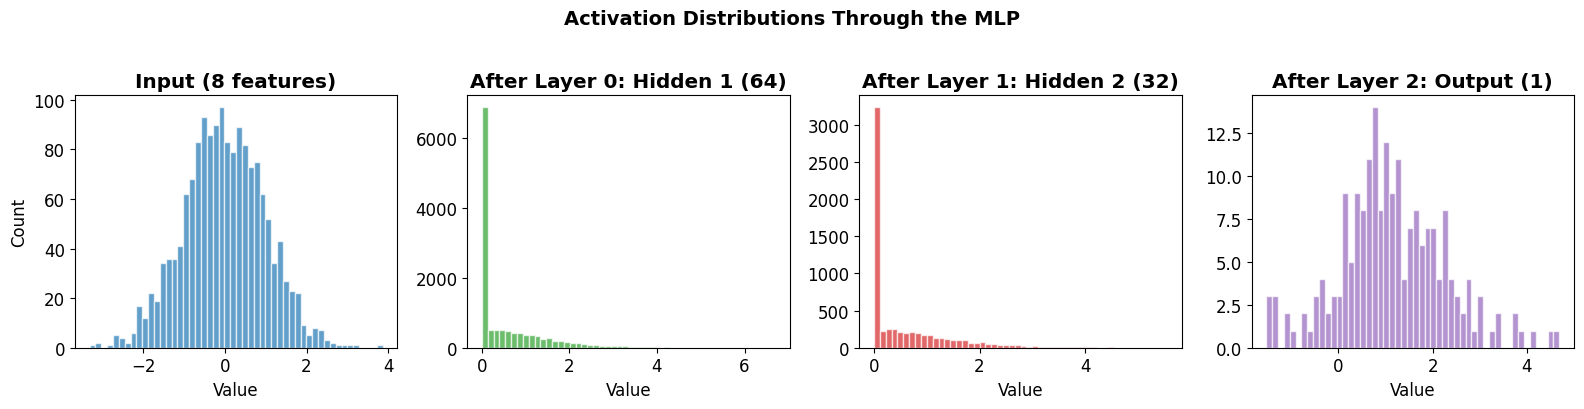

With He initialization and ReLU activations, values stay in a reasonable range.
This indicates stable activations.


In [18]:
# @title Visualize: Forward Pass Through the Network { display-mode: "form" }

# Run a batch of inputs and visualize activations at each layer
key = jax.random.PRNGKey(99)
x_batch = jax.random.normal(key, (200, 8))

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Input distribution
axes[0].hist(x_batch.flatten(), bins=50, color='#1f77b4', alpha=0.7, edgecolor='white')
axes[0].set_title('Input (8 features)', fontweight='bold')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Count')

# Activations at each layer
activations = x_batch
for i, (w, b) in enumerate(params):
    activations = activations @ w + b
    if i < len(params) - 1:
        activations = jnp.maximum(activations, 0)  # ReLU

    ax = axes[i + 1]
    data = activations.flatten()
    ax.hist(np.array(data), bins=50, color=['#2ca02c', '#d62728', '#9467bd'][i],
            alpha=0.7, edgecolor='white')
    layer_name = f'Hidden {i+1} ({activations.shape[1]})' if i < len(params) - 1 else f'Output ({activations.shape[1]})'
    ax.set_title(f'After Layer {i}: {layer_name}', fontweight='bold')
    ax.set_xlabel('Value')

fig.suptitle('Activation Distributions Through the MLP', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("With He initialization and ReLU activations, values stay in a reasonable range.")
print("This indicates stable activations.")


---

# Exercises

Test your understanding with these challenges:

1. **Modify the MLP architecture**: Change `layer_sizes` to `[8, 128, 64, 32, 1]` and re-run the forward pass. How does the output change? How do the activation distributions compare?

2. **PRNG key reuse bug**: In the `init_mlp_params` function, try replacing `key, w_key, b_key = jax.random.split(key, 3)` with just using `key` directly for every layer (no splitting). Run the forward pass — what goes wrong?

3. **Immutability exercise**: Create a `(3, 3)` identity matrix using `jnp.eye(3)`. Then use `.at[].set()` to set all diagonal elements to `5.0` and all off-diagonal elements in the first row to `-1.0`. Verify the original matrix is unchanged.

4. **Tracing surprise**: Write a function that uses a Python `print()` to display intermediate values, then wrap it with `@jax.jit`. Call it twice with different inputs. What do you observe? How would you fix it using `jax.debug.print()`?

---

# 8. Summary — What To Do Next

## Key Takeaways

1. **JAX is a transformation system**, not just "NumPy on GPU." The API compatibility is a convenience; the power is in [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html), [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html), [`vmap`](https://jax.readthedocs.io/en/latest/_autosummary/jax.vmap.html), and their composition.

2. **Immutability is fundamental**, not a restriction. Use [`.at[].set()`](https://jax.readthedocs.io/en/latest/_autosummary/jax.Array.at.html) for updates. Use functional paradigms instead of attempting to mutate structures.

3. **Explicit PRNG keys** replace global random state. The pattern is always: `key, subkey = jax.random.split(key)`, then draw from `subkey`. This guarantees reproducibility and works correctly under all transformations.

4. **JAX defaults to float32**. Be aware of this when porting NumPy code, and always use `block_until_ready()` when timing.

5. **Pure functions in, transformed functions out.** Side effects (mutation, prints, global state) are invisible to JAX's transformations and will cause subtle bugs.

## What This Notebook Built

We implemented a **2-hidden-layer MLP forward pass** with:
- He-initialized weights via proper PRNG key splitting
- A pure, functional forward pass with no hidden state
- Verified reproducibility

## What's Next

In **[Notebook 02: Autodiff and JIT](02_autodiff.ipynb)**, we'll take this MLP and:
- Compute gradients of a loss function through the entire network using [`grad`](https://jax.readthedocs.io/en/latest/_autosummary/jax.grad.html)
- Compile the training step with [`jit`](https://jax.readthedocs.io/en/latest/_autosummary/jax.jit.html) for 10-100x speedups
- Build a complete gradient descent training loop

The forward pass you built here becomes a training loop there.